<a href="https://colab.research.google.com/github/cliteka-cell/Apple-Trading-Algorithm/blob/main/Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_496/2034584831.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', period='2y')['Close']
[*********************100%***********************]  1 of 1 completed


--- STRATEGY PERFORMANCE REPORT ---
FAST STRATEGY (30/50):  Accuracy: 60.0% | Total Profit: 54.2%
SLOW STRATEGY (120):   Accuracy: 50.0% | Total Profit: 8.5%
BUY & HOLD APPLE:      Total Profit: 45.9%


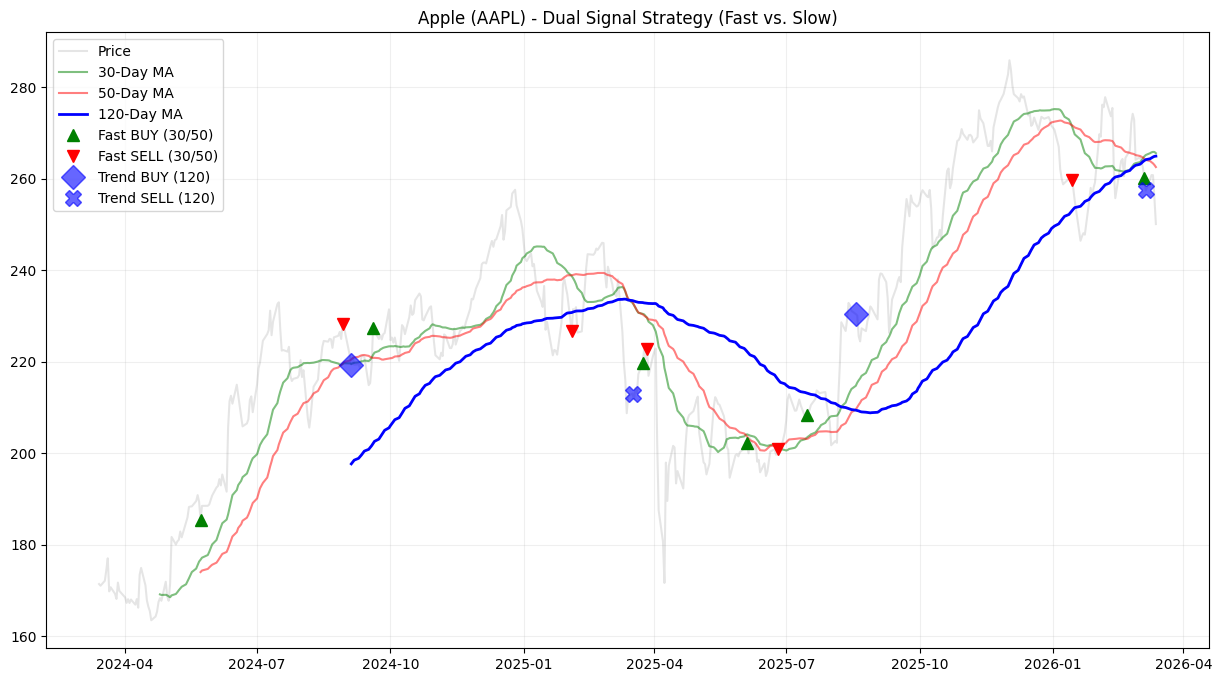

In [ ]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Pulling the Apple data:
df = yf.download('AAPL', period='2y')['Close']
apple_df = df

# Making the 3 different Moving Averages; 1 for short time frame, 1 for medium and 1 for long:
apple_df['MA30']  = apple_df['AAPL'].rolling(window=30).mean()
apple_df['MA50']  = apple_df['AAPL'].rolling(window=50).mean()
apple_df['MA120'] = apple_df['AAPL'].rolling(window=120).mean()

# Making 2 separate signals for short term and long term:

# Signal 1: The short term "Fast" 30/50 Crossover
apple_df['Sig_Fast'] = (apple_df['MA30'] > apple_df['MA50']).astype(float)
apple_df['Pos_Fast'] = apple_df['Sig_Fast'].diff()

# Signal 2: The long term "Trend" Filter (Price/MAs vs 120)
apple_df['Sig_Slow'] = (apple_df['MA50'] > apple_df['MA120']).astype(float)
apple_df['Pos_Slow'] = apple_df['Sig_Slow'].diff()

# Separate the dates for plotting
buy_fast = apple_df[apple_df['Pos_Fast'] == 1].index
sell_fast = apple_df[apple_df['Pos_Fast'] == -1].index

buy_slow = apple_df[apple_df['Pos_Slow'] == 1].index
sell_slow = apple_df[apple_df['Pos_Slow'] == -1].index

# Visualization
plt.figure(figsize=(15, 8))

# Background lines
plt.plot(apple_df.index, apple_df['AAPL'], label='Price', color='gray', alpha=0.2)
plt.plot(apple_df.index, apple_df['MA30'],  label='30-Day MA', color='green', alpha=0.5)
plt.plot(apple_df.index, apple_df['MA50'],  label='50-Day MA', color='red', alpha=0.5)
plt.plot(apple_df.index, apple_df['MA120'], label='120-Day MA', color='blue', linewidth=2)

# FAST SIGNAL MARKERS (Green/Red)
plt.plot(buy_fast, apple_df.loc[buy_fast, 'AAPL'], '^', markersize=8, color='g', label='Fast BUY (30/50)', lw=0)
plt.plot(sell_fast, apple_df.loc[sell_fast, 'AAPL'], 'v', markersize=8, color='r', label='Fast SELL (30/50)', lw=0)

# SLOW SIGNAL MARKERS (Blue)
plt.plot(buy_slow, apple_df.loc[buy_slow, 'AAPL'], 'D', markersize=12, color='blue', label='Trend BUY (120)', alpha=0.6, lw=0)
plt.plot(sell_slow, apple_df.loc[sell_slow, 'AAPL'], 'X', markersize=12, color='blue', label='Trend SELL (120)', alpha=0.6, lw=0)

# Let us simulate the accuracy of the algorithm

def calculate_performance(df, position_col, price_col):
    # Create a list of profits for each completed trade
    trades = []
    buy_price = 0
    in_position = False

    for i in range(len(df)):
        # Buy Signal
        if df[position_col].iloc[i] == 1:
            buy_price = df[price_col].iloc[i]
            in_position = True
        # Sell Signal
        elif df[position_col].iloc[i] == -1 and in_position:
            sell_price = df[price_col].iloc[i]
            profit_pct = (sell_price - buy_price) / buy_price
            trades.append(profit_pct)
            in_position = False

    if not trades: return 0, 0

    # Calculate Accuracy
    winning_trades = [t for t in trades if t > 0]
    accuracy = (len(winning_trades) / len(trades)) * 100

    # Calculate Total Return (Compounded)
    total_return = 1.0
    for t in trades:
        total_return *= (1 + t)
    final_return_pct = (total_return - 1) * 100

    return accuracy, final_return_pct

# --- RUN THE CALCULATION ---
acc_fast, ret_fast = calculate_performance(apple_df, 'Pos_Fast', 'AAPL')
acc_slow, ret_slow = calculate_performance(apple_df, 'Pos_Slow', 'AAPL')

print("--- STRATEGY PERFORMANCE REPORT ---")
print(f"FAST STRATEGY (30/50):  Accuracy: {acc_fast:.1f}% | Total Profit: {ret_fast:.1f}%")
print(f"SLOW STRATEGY (120):   Accuracy: {acc_slow:.1f}% | Total Profit: {ret_slow:.1f}%")

# Benchmark: What if you just held the stock?
hold_return = ((apple_df['AAPL'].iloc[-1] - apple_df['AAPL'].iloc[0]) / apple_df['AAPL'].iloc[0]) * 100
print(f"BUY & HOLD APPLE:      Total Profit: {hold_return:.1f}%")

plt.title('Apple (AAPL) - Dual Signal Strategy (Fast vs. Slow)')
plt.legend(loc='best')
plt.grid(True, alpha=0.2)
plt.show()

In [24]:
import sqlite3

conn = sqlite3.connect('trading_portfolio.db')
cursor = conn.cursor()

cursor.execute('''
CREATE TABLE IF NOT EXISTS algo_trades (
    date TEXT,
    asset TEXT,
    signal_type TEXT,
    price REAL
)
''')

# 3. Looping through the Buy Dates and Inserting them
for date in buy_dates:
    price = apple_df.loc[date, 'AAPL']
    cursor.execute("INSERT INTO algo_trades (date, asset, signal_type, price) VALUES (?, ?, ?, ?)",
                   (str(date.date()), 'AAPL', 'BUY', float(price)))

# 4. Looping through the Sell Dates and Inserting them
for date in sell_dates:
    price = apple_df.loc[date, 'AAPL']
    cursor.execute("INSERT INTO algo_trades (date, asset, signal_type, price) VALUES (?, ?, ?, ?)",
                   (str(date.date()), 'AAPL', 'SELL', float(price)))

conn.commit()
print(f"Successfully moved {len(buy_dates) + len(sell_dates)} signals into the SQL database!")

Successfully moved 6 signals into the SQL database!


In [26]:
query = """
SELECT * FROM algo_trades
WHERE asset = 'AAPL'
AND signal_type = 'BUY'
AND price > 200
ORDER BY date DESC
"""

filtered_trades = pd.read_sql_query(query, conn)
print(filtered_trades)

         date asset signal_type       price
0  2026-03-05  AAPL         BUY  260.290009
1  2025-08-18  AAPL         BUY  230.450760
2  2024-09-19  AAPL         BUY  227.376373
